# NER Dataset Creation

This notebook covers how the dataset for training the mountain-name NER
model was built.


*   **Dataset source:** Gepe55o/mountain-ner-dataset (HuggingFace Hub)
*   **Original labeling format:** binary (0 = not a mountain, 1 = mountain).
Later in this notebook we also convert it to the BIO scheme and compare
the two formats.

This dataset already has around 111k labeled examples, built
from NERetrieve and Few-NERD, so there was no need to label data manually
or generate it with an LLM.





In [ ]:
!pip install datasets -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from datasets import load_dataset

ds = load_dataset("Gepe55o/mountain-ner-dataset")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 88619
    })
    test: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 22110
    })
})


In [ ]:
import pandas as pd

df = pd.DataFrame(ds["train"][:10])
df

,tokens,tags
0,"[On, May, 23,, 2019,, RIKEN, announced, that, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[Lindsey, Mountain, is, a, summit, in, Iron, C...","[1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[Jesus, seems, to, recoil, from, the, impendin...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[In, 2016,, Marais, participated, in, the, Two...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,"[Initial, extrapolations, placed, Cooper's, la...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
5,"[The, Jatayu, and, Sparrow, Conservation, Bree...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,"[Principal, photography, took, place, between,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,"[The, are, an, active, volcanic, complex, in, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,"[Olene, dudgeoni, is, a, moth, of, the, subfam...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,"[Puck's, Glen, is, a, river-formed, ravine, on...","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
for i in range(5):
    example = ds["train"][i]
    print(" ".join(f"{t}[{l}]" for t, l in zip(example["tokens"], example["tags"])))
    print()

On[0] May[0] 23,[0] 2019,[0] RIKEN[0] announced[0] that[0] the[0] supercomputer[0] was[0] to[0] be[0] named[0] Fugaku.[0] In[0] August[0] 2019,[0] the[0] logo[0] for[0] Fugaku[0] was[0] unveiled;[0] it[0] depicts[0] Mount[1] Fuji,[1] symbolising[0] Fugaku's[0] high[0] performance[0] and[0] the[0] wide[0] range[0] of[0] its[0] users.[0] In[0] November[0] 2019,[0] the[0] prototype[0] of[0] Fugaku[0] won[0] first[0] place[0] in[0] the[0] Green500[0] list.[0] Shipment[0] of[0] the[0] equipment[0] racks[0] to[0] the[0] RIKEN[0] facility[0] began[0] on[0] December[0] 2,[0] 2019,[0] and[0] was[0] completed[0] on[0] May[0] 13,[0] 2020.[0] In[0] June[0] 2020,[0] Fugaku[0] became[0] the[0] fastest[0] supercomputer[0] in[0] the[0] world[0] in[0] the[0] TOP500[0] list,[0] displacing[0] the[0] IBM[0] Summit.[0]

Lindsey[1] Mountain[1] is[0] a[0] summit[1] in[0] Iron[0] County[0] in[0] the[0] U.S.[0] state[0] of[0] Missouri.[0] The[0] summit[1] has[0] an[0] elevation[0] of[0] .[0]

Jesus[0] seems[0]

In [ ]:
print(f"Train size: {len(ds['train'])}")
print(f"Test size: {len(ds['test'])}")

lengths = [len(ex["tokens"]) for ex in ds["train"]]
print(f"\nAverage sentence length: {sum(lengths)/len(lengths):.1f} tokens")
print(f"Min sentence length: {min(lengths)}")
print(f"Max sentence length: {max(lengths)}")

Train size: 88619
Test size: 22110

Average sentence length: 78.2 tokens
Min sentence length: 5
Max sentence length: 805


Mountain tokens: 287253 (4.15%)
Other tokens: 6640565


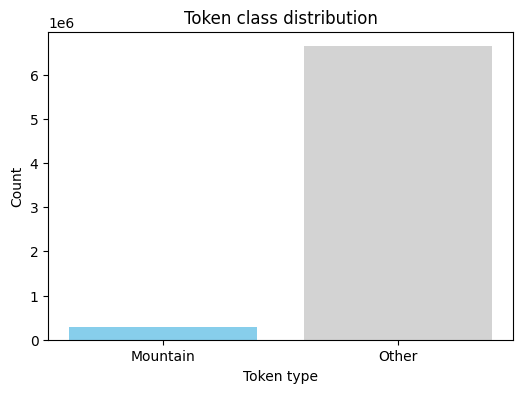

In [ ]:
import matplotlib.pyplot as plt

mountain_tokens = sum(sum(ex["tags"]) for ex in ds["train"])
total_tokens = sum(len(ex["tags"]) for ex in ds["train"])
other_tokens = total_tokens - mountain_tokens
print(f"Mountain tokens: {mountain_tokens} ({mountain_tokens/total_tokens*100:.2f}%)")
print(f"Other tokens: {other_tokens}")

plt.figure(figsize=(6, 4))
plt.bar(["Mountain", "Other"], [mountain_tokens, other_tokens], color=["skyblue", "lightgray"])

plt.title("Token class distribution")
plt.xlabel("Token type")
plt.ylabel("Count")

plt.show()

In [ ]:
split = ds["train"].train_test_split(test_size=0.1, seed=42)
train_data = split["train"]
val_data = split["test"]
test_data = ds["test"]

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

Train: 79757, Val: 8862, Test: 22110


In [ ]:
import os

# project folder on Google Drive
DATA_DIR = "/content/drive/MyDrive/mountain_ner/data"
os.makedirs(DATA_DIR, exist_ok=True)

print(f"Data will be saved to: {DATA_DIR}")

Data will be saved to: /content/drive/MyDrive/mountain_ner/data


In [ ]:
import json

def save_jsonl(dataset, filepath):
    with open(filepath, "w", encoding="utf-8") as f:
        for example in dataset:
            record = {
                "tokens": list(example["tokens"]),
                "tags": [int(t) for t in example["tags"]]  # ensure plain ints, not numpy
            }
            f.write(json.dumps(record) + "\n")

files_to_save = [
    (train_data, f"{DATA_DIR}/mountain_ner_train.jsonl"),
    (val_data, f"{DATA_DIR}/mountain_ner_val.jsonl"),
    (test_data, f"{DATA_DIR}/mountain_ner_test.jsonl"),
]

for data, filepath in files_to_save:
    save_jsonl(data, filepath)
    print(f"File '{filepath}' saved ({len(data)} examples)")

File '/content/drive/MyDrive/mountain_ner/data/mountain_ner_train.jsonl' saved (79757 examples)
File '/content/drive/MyDrive/mountain_ner/data/mountain_ner_val.jsonl' saved (8862 examples)
File '/content/drive/MyDrive/mountain_ner/data/mountain_ner_test.jsonl' saved (22110 examples)


## Converting to BIO scheme

The binary labels are converted to the standard BIO scheme (B-MOUNTAIN /
I-MOUNTAIN / O), which distinguishes adjacent separate entities — something
the binary format can't do. Both formats are compared below before deciding
which one to use for training.

In [ ]:
def convert_to_bio(tags):
    bio_tags = []
    prev_tag = 0
    for tag in tags:
        if tag == 0:
            bio_tags.append("O")
        elif tag == 1 and prev_tag == 0:
            bio_tags.append("B-MOUNTAIN")
        else:  # tag == 1 and prev_tag == 1
            bio_tags.append("I-MOUNTAIN")
        prev_tag = tag
    return bio_tags

# test on one example
example = ds["train"][0]
print("Tokens:", example["tokens"])
print("Binary:", example["tags"])
print("BIO:   ", convert_to_bio(example["tags"]))

Tokens: ['On', 'May', '23,', '2019,', 'RIKEN', 'announced', 'that', 'the', 'supercomputer', 'was', 'to', 'be', 'named', 'Fugaku.', 'In', 'August', '2019,', 'the', 'logo', 'for', 'Fugaku', 'was', 'unveiled;', 'it', 'depicts', 'Mount', 'Fuji,', 'symbolising', "Fugaku's", 'high', 'performance', 'and', 'the', 'wide', 'range', 'of', 'its', 'users.', 'In', 'November', '2019,', 'the', 'prototype', 'of', 'Fugaku', 'won', 'first', 'place', 'in', 'the', 'Green500', 'list.', 'Shipment', 'of', 'the', 'equipment', 'racks', 'to', 'the', 'RIKEN', 'facility', 'began', 'on', 'December', '2,', '2019,', 'and', 'was', 'completed', 'on', 'May', '13,', '2020.', 'In', 'June', '2020,', 'Fugaku', 'became', 'the', 'fastest', 'supercomputer', 'in', 'the', 'world', 'in', 'the', 'TOP500', 'list,', 'displacing', 'the', 'IBM', 'Summit.']
Binary: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [ ]:
for i in range(3):
    example = ds["train"][i]
    bio_tags = convert_to_bio(example["tags"])
    print(" ".join(f"{t}[{tag}]" for t, tag in zip(example["tokens"], bio_tags)))
    print()

On[O] May[O] 23,[O] 2019,[O] RIKEN[O] announced[O] that[O] the[O] supercomputer[O] was[O] to[O] be[O] named[O] Fugaku.[O] In[O] August[O] 2019,[O] the[O] logo[O] for[O] Fugaku[O] was[O] unveiled;[O] it[O] depicts[O] Mount[B-MOUNTAIN] Fuji,[I-MOUNTAIN] symbolising[O] Fugaku's[O] high[O] performance[O] and[O] the[O] wide[O] range[O] of[O] its[O] users.[O] In[O] November[O] 2019,[O] the[O] prototype[O] of[O] Fugaku[O] won[O] first[O] place[O] in[O] the[O] Green500[O] list.[O] Shipment[O] of[O] the[O] equipment[O] racks[O] to[O] the[O] RIKEN[O] facility[O] began[O] on[O] December[O] 2,[O] 2019,[O] and[O] was[O] completed[O] on[O] May[O] 13,[O] 2020.[O] In[O] June[O] 2020,[O] Fugaku[O] became[O] the[O] fastest[O] supercomputer[O] in[O] the[O] world[O] in[O] the[O] TOP500[O] list,[O] displacing[O] the[O] IBM[O] Summit.[O]

Lindsey[B-MOUNTAIN] Mountain[I-MOUNTAIN] is[O] a[O] summit[B-MOUNTAIN] in[O] Iron[O] County[O] in[O] the[O] U.S.[O] state[O] of[O] Missouri.[O] The[O] summit[B-MOUNTAIN] h

### Checking label quality

Mountain names should almost always be capitalized, so a lowercase
"mountain"-tagged token likely signals label noise. Checking how common
this is below.

In [ ]:
# Check how many "mountain" tagged tokens are lowercase common nouns
lowercase_mountain_tokens = []

for ex in ds["train"]:
    for token, tag in zip(ex["tokens"], ex["tags"]):
        if tag == 1 and token[0].islower():
            lowercase_mountain_tokens.append(token)

print(f"Total mountain-tagged tokens (lowercase): {len(lowercase_mountain_tokens)}")
print(f"Total mountain-tagged tokens (overall): {mountain_tokens}")
print(f"Share: {len(lowercase_mountain_tokens) / mountain_tokens * 100:.2f}%")

Total mountain-tagged tokens (lowercase): 18979
Total mountain-tagged tokens (overall): 287253
Share: 6.61%


In [ ]:
from collections import Counter

lowercase_counts = Counter(lowercase_mountain_tokens)
print("Most common lowercase tokens tagged as 'mountain':")
for word, count in lowercase_counts.most_common(15):
    print(f"  {word}: {count}")

Most common lowercase tokens tagged as 'mountain':
  the: 2695
  de: 1487
  mountain: 1036
  of: 898
  summit: 784
  mountains: 590
  du: 528
  massif: 476
  del: 429
  peak: 418
  volcanic: 388
  range: 274
  la: 244
  volcano: 239
  ridge: 227


### Data quality observation

The hypothesis is confirmed: 6.61% of tokens tagged as "mountain" are
lowercase. Manual inspection shows two patterns:
1. Legitimate lowercase words that are part of multi-word mountain names
   in non-English languages (de, du, del, la — French/Spanish prepositions).
2. Generic geographic nouns (summit, peak, ridge, volcano, mountain) that
   are sometimes tagged even when used generically rather than as part of
   a proper name (e.g. "is a summit" vs "Lindsey Mountain's summit").

Most of the noise comes from the second pattern. No filtering is applied
at this stage — the labels are used as-is, with this in mind for later
error analysis.

In [ ]:
train_data_bio = train_data.map(lambda ex: {"bio_tags": convert_to_bio(ex["tags"])})
val_data_bio = val_data.map(lambda ex: {"bio_tags": convert_to_bio(ex["tags"])})
test_data_bio = test_data.map(lambda ex: {"bio_tags": convert_to_bio(ex["tags"])})

# compare label distribution between formats
from collections import Counter
bio_counts = Counter(tag for ex in train_data_bio for tag in ex["bio_tags"])

print("BIO tag distribution in train set:")
print(f"  O (not mountain):        {bio_counts['O']}")
print(f"  B-MOUNTAIN (entity start): {bio_counts['B-MOUNTAIN']}")
print(f"  I-MOUNTAIN (entity continuation): {bio_counts['I-MOUNTAIN']}")

BIO tag distribution in train set:
  O (not mountain):        5973521
  B-MOUNTAIN (entity start): 145843
  I-MOUNTAIN (entity continuation): 112049


In [ ]:
def save_jsonl_bio(dataset, filepath):
    with open(filepath, "w", encoding="utf-8") as f:
        for example in dataset:
            record = {
                "tokens": list(example["tokens"]),
                "bio_tags": list(example["bio_tags"])
            }
            f.write(json.dumps(record) + "\n")

files_to_save_bio = [
    (train_data_bio, f"{DATA_DIR}/mountain_ner_train_bio.jsonl"),
    (val_data_bio, f"{DATA_DIR}/mountain_ner_val_bio.jsonl"),
    (test_data_bio, f"{DATA_DIR}/mountain_ner_test_bio.jsonl"),
]

for data, filepath in files_to_save_bio:
    save_jsonl_bio(data, filepath)
    print(f"File '{filepath}' saved ({len(data)} examples)")

File '/content/drive/MyDrive/mountain_ner/data/mountain_ner_train_bio.jsonl' saved (79757 examples)
File '/content/drive/MyDrive/mountain_ner/data/mountain_ner_val_bio.jsonl' saved (8862 examples)
File '/content/drive/MyDrive/mountain_ner/data/mountain_ner_test_bio.jsonl' saved (22110 examples)


## Summary

The final dataset is based on **Gepe55o/mountain-ner-dataset** (HuggingFace
Hub), chosen for its size (~111k labeled examples) and readiness — it
removed the need for manual labeling or LLM-based generation within the
test's time constraints.

**Splits:** train (79,757) / val (8,862, carved out from the original train
set) / test (22,110, kept untouched from the original dataset) — saved as
JSON Lines files in both formats: binary (`mountain_ner_train.jsonl`,
`mountain_ner_val.jsonl`, `mountain_ner_test.jsonl`) and BIO
(`mountain_ner_train_bio.jsonl`, `mountain_ner_val_bio.jsonl`,
`mountain_ner_test_bio.jsonl`).

**Labeling format:** the dataset uses binary tags (0/1). It was also
converted to the standard BIO scheme (B-MOUNTAIN / I-MOUNTAIN / O) to check
whether it fits the task better. BIO distribution in the train set: 145,843
B-MOUNTAIN vs 112,049 I-MOUNTAIN tags, showing that many mountain entities
are short (~1.8 tokens on average) and that adjacent separate entities are
common — so BIO could reduce entity-boundary ambiguity better than the
binary scheme.

**Decision:** for this iteration, the **binary format** is used for
training, given the limited time available and the moderate expected
impact of switching to BIO. The BIO conversion logic is implemented and
validated above, and can be swapped in easily if validation results show
the binary format is a limiting factor.

**Known limitations:**
- 6.61% of tokens tagged as "mountain" are lowercase, suggesting label
  noise — mostly generic nouns (summit, peak, ridge, volcano) tagged even
  when used non-specifically, and some legitimate lowercase prepositions
  in multi-word names (de, du, del, la).
- No manual filtering of ambiguous cases was performed, to keep the
  process reproducible and time-efficient.